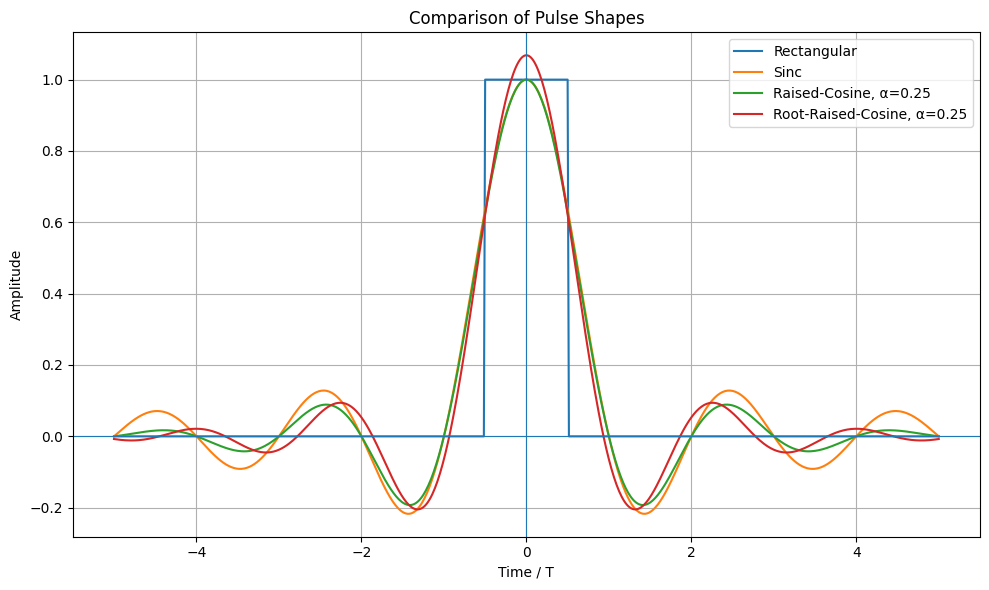

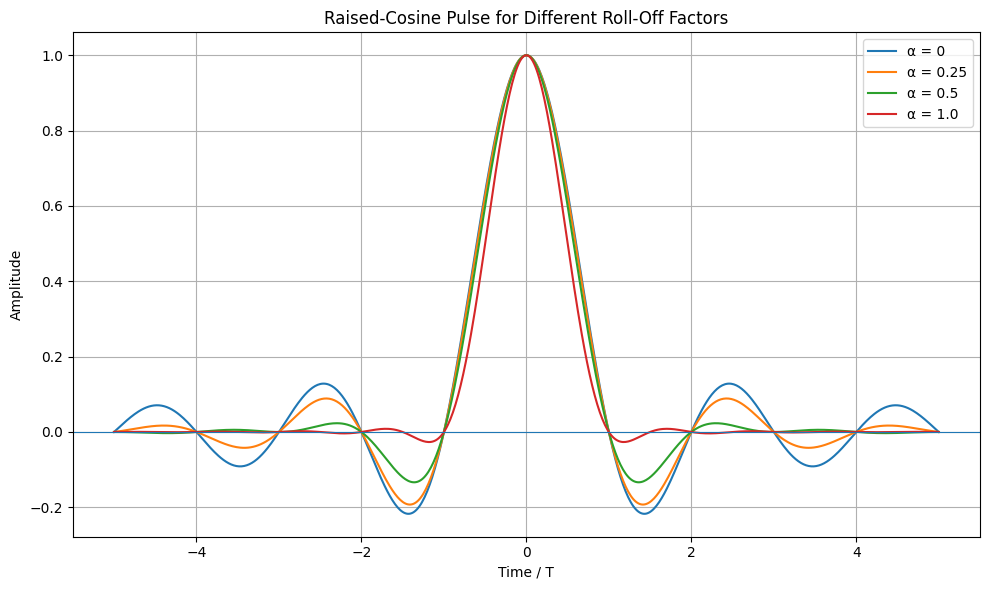

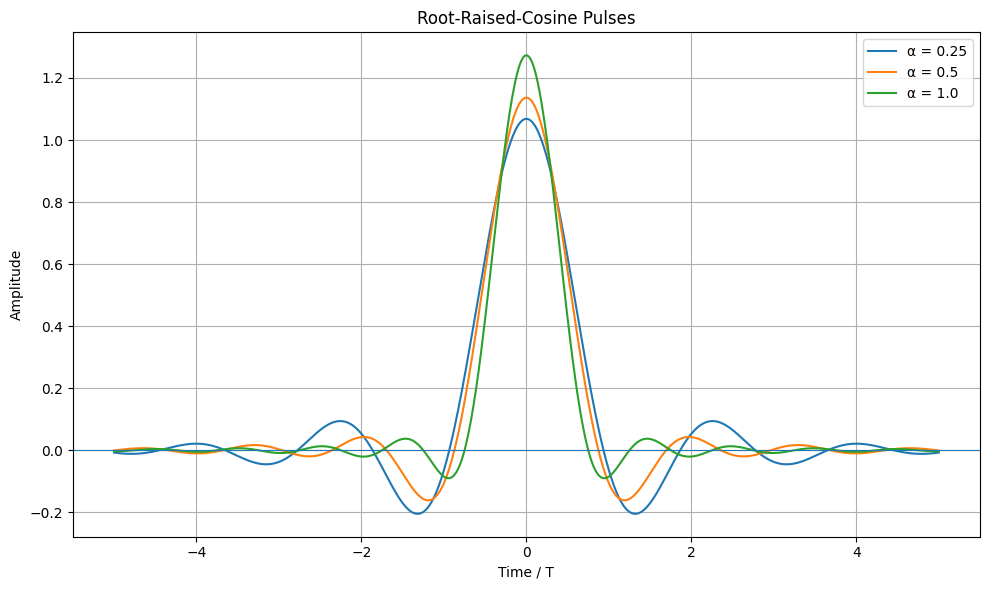

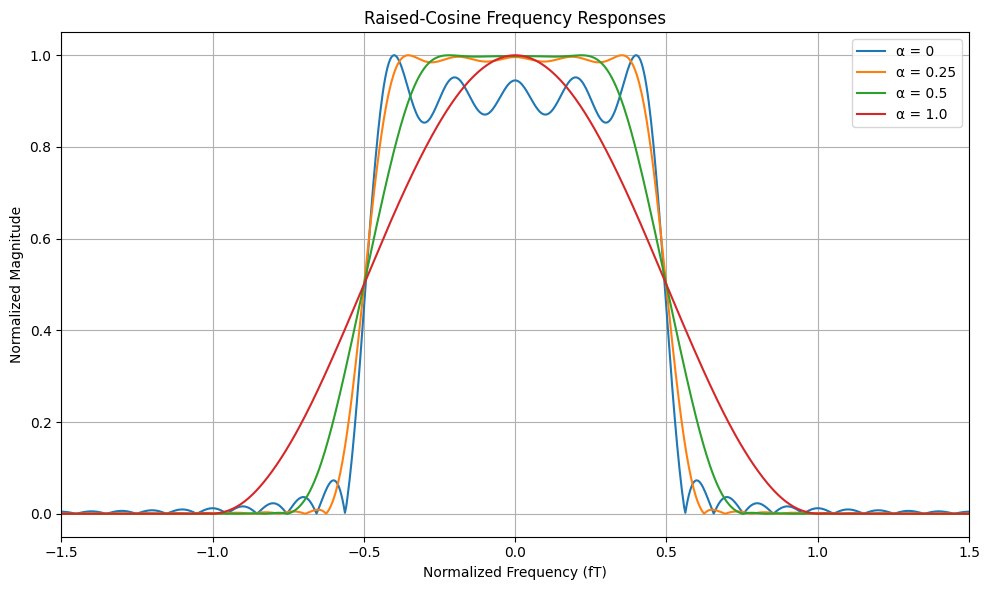

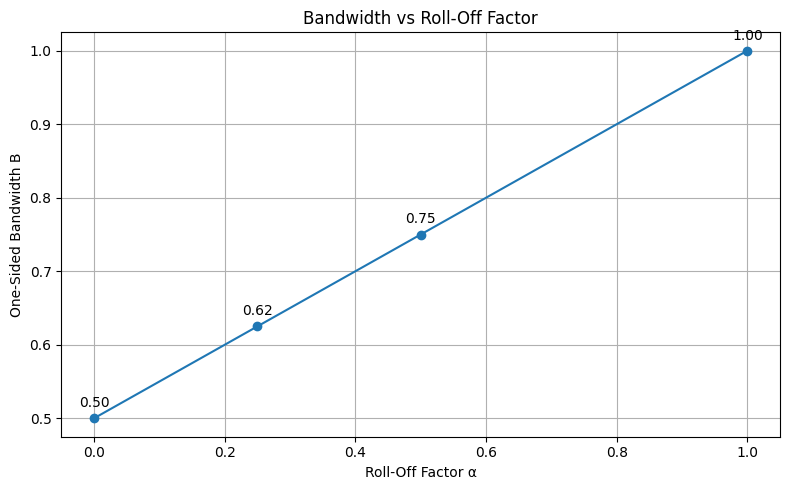


Original Symbol Sequence:
[-1  1 -1 -1 -1  1 -1 -1 -1  1 -1 -1 -1 -1  1 -1  1  1  1 -1]


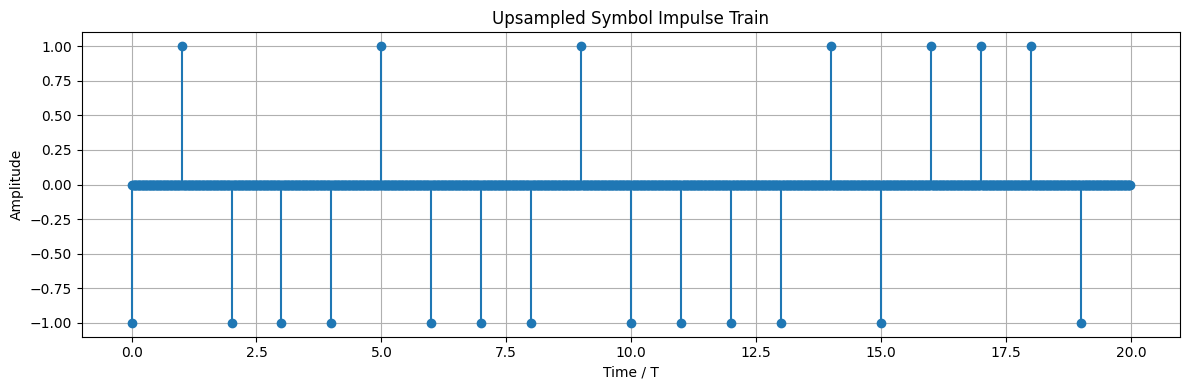

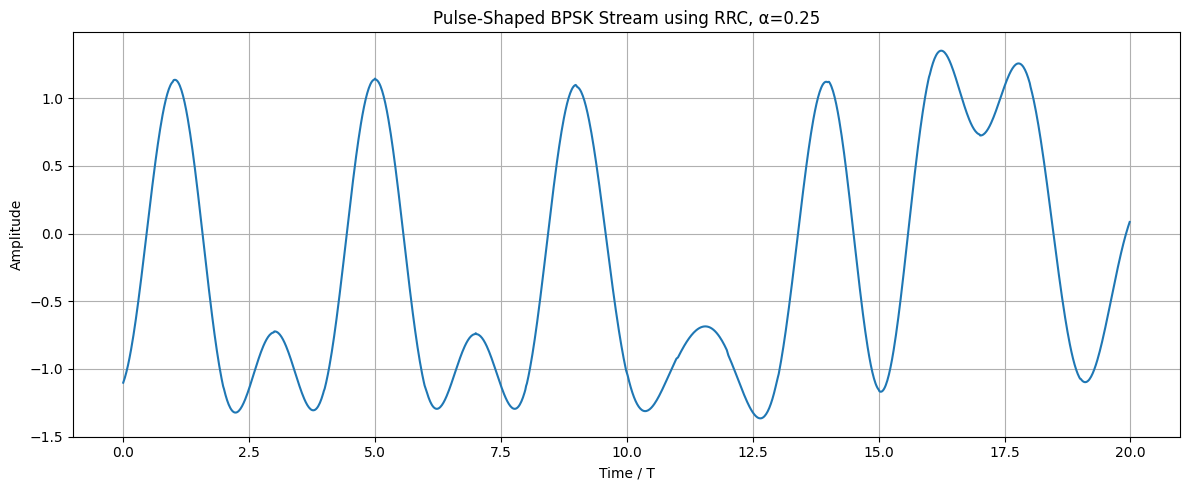


NYQUIST ZERO-CROSSING VERIFICATION

Roll-off factor α = 0.25
Sample	Time/T	RC amplitude
-5	-5.0	+5.250331e-18
-4	-4.0	-1.299391e-17
-3	-3.0	+2.205139e-17
-2	-2.0	-3.061617e-17
-1	-1.0	+3.675232e-17
+0	+0.0	+1.000000e+00
+1	+1.0	+3.675232e-17
+2	+2.0	-3.061617e-17
+3	+3.0	+2.205139e-17
+4	+4.0	-1.299391e-17
+5	+5.0	+5.250331e-18

Roll-off factor α = 0.5
Sample	Time/T	RC amplitude
-5	-5.0	-4.972795e-34
-4	-4.0	+2.598781e-18
-3	-3.0	+8.951032e-34
-2	-2.0	-1.299391e-17
-1	-1.0	+3.061617e-17
+0	+0.0	+1.000000e+00
+1	+1.0	+3.061617e-17
+2	+2.0	-1.299391e-17
+3	+3.0	+8.951032e-34
+4	+4.0	+2.598781e-18
+5	+5.0	-4.972795e-34

Roll-off factor α = 1.0
Sample	Time/T	RC amplitude
-5	-5.0	+3.937547e-19
-4	-4.0	+6.187574e-19
-3	-3.0	+1.113763e-18
-2	-2.0	+2.598781e-18
-1	-1.0	+1.299391e-17
+0	+0.0	+1.000000e+00
+1	+1.0	+1.299391e-17
+2	+2.0	+2.598781e-18
+3	+3.0	+1.113763e-18
+4	+4.0	+6.187574e-19
+5	+5.0	+3.937547e-19


MANDATORY RC INTEGER-SYMBOL SAMPLING TABLE
 Symbol Interval k  Time t/T  RC Sam

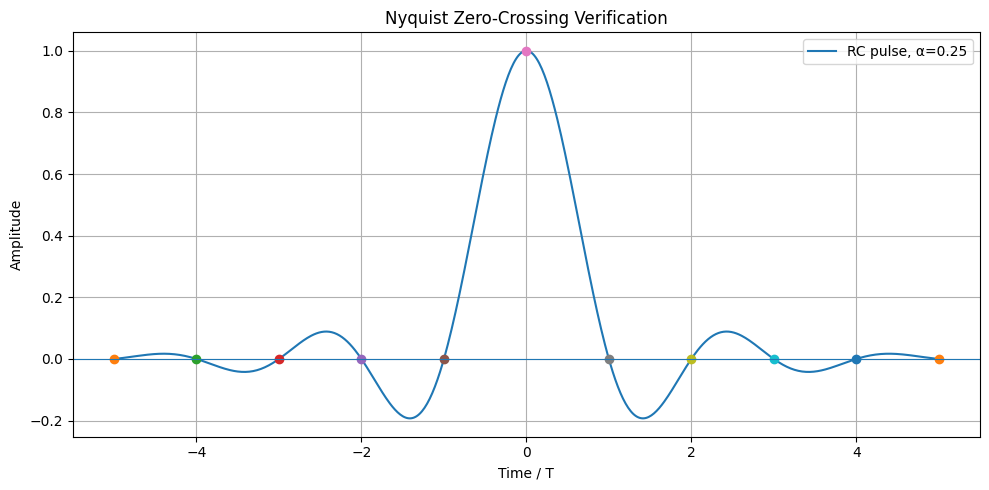

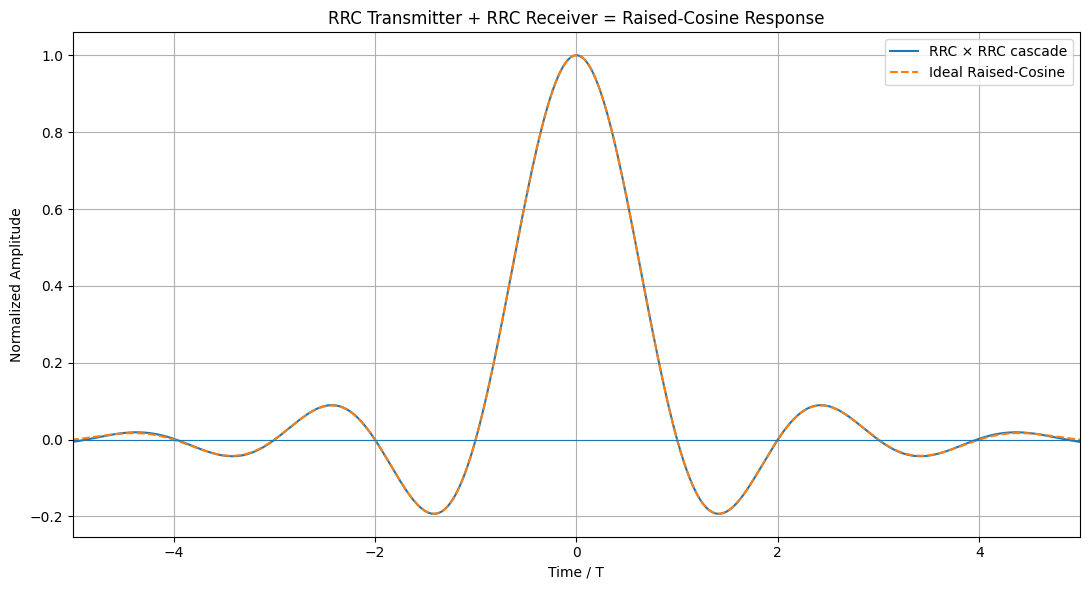



RRC CASCADE INTEGER-SYMBOL VALIDATION
 Symbol Interval k  Time/T  Cascade RC Value
                -5      -5         -0.005895
                -4      -4          0.002263
                -3      -3         -0.000827
                -2      -2          0.000098
                -1      -1          0.000217
                 0       0          1.000000
                 1       1          0.000217
                 2       2          0.000098
                 3       3         -0.000827
                 4       4          0.002263
                 5       5         -0.005895


NYQUIST ZERO-CROSSING ERROR
k=-5: zero-crossing error = 5.895294e-03
k=-4: zero-crossing error = 2.262782e-03
k=-3: zero-crossing error = 8.267611e-04
k=-2: zero-crossing error = 9.785248e-05
k=-1: zero-crossing error = 2.168535e-04
k=+0: centre value = 1.000000e+00
k=+1: zero-crossing error = 2.168535e-04
k=+2: zero-crossing error = 9.785248e-05
k=+3: zero-crossing error = 8.267611e-04
k=+4: zero-crossing error = 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import convolve

# ============================================================
# EXPERIMENT 7: PULSE SHAPING AND THE NYQUIST CRITERION
# ============================================================

# -----------------------------
# Basic parameters
# -----------------------------
T = 1.0                 # Symbol period
sps = 64                # Samples per symbol
span = 10               # Filter span in symbols
alphas = [0, 0.25, 0.5, 1.0]

dt = T / sps

# Time vector
t = np.arange(-span*T/2, span*T/2 + dt, dt)


# ============================================================
# 1. RECTANGULAR PULSE
# ============================================================

def rectangular_pulse(t, T=1.0):
    """
    Rectangular pulse of duration T.
    """
    return np.where(np.abs(t) <= T/2, 1.0, 0.0)


# ============================================================
# 2. SINC PULSE
# ============================================================

def sinc_pulse(t, T=1.0):
    """
    Ideal Nyquist sinc pulse:
        h(t) = sinc(t/T)
    """

    return np.sinc(t / T)


# ============================================================
# 3. RAISED-COSINE PULSE
# ============================================================

def raised_cosine(t, T=1.0, alpha=0.25):
    """
    Raised-cosine pulse:

    h(t) = sinc(t/T)
           * cos(pi*alpha*t/T)
           --------------------------------
           1 - (2*alpha*t/T)^2

    Special cases are handled explicitly.
    """

    x = t / T
    h = np.zeros_like(x, dtype=float)

    # alpha = 0 gives sinc pulse
    if alpha == 0:
        return np.sinc(x)

    # General points
    numerator = np.sinc(x) * np.cos(np.pi * alpha * x)
    denominator = 1 - (2 * alpha * x)**2

    # Avoid division by zero
    regular = np.abs(denominator) > 1e-12
    h[regular] = numerator[regular] / denominator[regular]

    # t = ±T/(2alpha)
    singular = ~regular

    # Limit at singularity
    h[singular] = (alpha / 2) * np.sin(np.pi / (2 * alpha))

    return h


# ============================================================
# 4. ROOT-RAISED-COSINE PULSE
# ============================================================

def root_raised_cosine(t, T=1.0, alpha=0.25):
    """
    Root-raised-cosine impulse response.

    h(t) =
    [sin(pi(1-alpha)t/T)
     + 4alpha(t/T)cos(pi(1+alpha)t/T)]
    /
    [pi(t/T)(1-(4alpha*t/T)^2)]

    Special cases:
        t = 0
        t = ±T/(4alpha)
    are handled explicitly.
    """

    x = t / T
    h = np.zeros_like(x, dtype=float)

    # alpha = 0 -> sinc
    if alpha == 0:
        return np.sinc(x)

    # Normal points
    numerator = (
        np.sin(np.pi * (1 - alpha) * x)
        + 4 * alpha * x * np.cos(np.pi * (1 + alpha) * x)
    )

    denominator = (
        np.pi * x * (1 - (4 * alpha * x)**2)
    )

    # Normal region
    regular = (
        (np.abs(x) > 1e-12)
        &
        (np.abs(1 - (4 * alpha * x)**2) > 1e-12)
    )

    h[regular] = numerator[regular] / denominator[regular]

    # --------------------------------------------------------
    # t = 0
    # --------------------------------------------------------
    zero = np.abs(x) <= 1e-12

    h[zero] = (
        1
        + alpha * (4 / np.pi - 1)
    )

    # --------------------------------------------------------
    # t = ±T/(4alpha)
    # --------------------------------------------------------
    singular = (
        (np.abs(1 - (4 * alpha * x)**2) <= 1e-12)
        &
        (~zero)
    )

    h[singular] = (
        alpha / np.sqrt(2)
        *
        (
            (1 + 2/np.pi)
            * np.sin(np.pi / (4 * alpha))
            +
            (1 - 2/np.pi)
            * np.cos(np.pi / (4 * alpha))
        )
    )

    return h


# ============================================================
# 5. PLOT TIME-DOMAIN PULSES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(t, rectangular_pulse(t, T),
         label="Rectangular")

plt.plot(t, sinc_pulse(t, T),
         label="Sinc")

plt.plot(t, raised_cosine(t, T, 0.25),
         label="Raised-Cosine, α=0.25")

plt.plot(t, root_raised_cosine(t, T, 0.25),
         label="Root-Raised-Cosine, α=0.25")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Time / T")
plt.ylabel("Amplitude")
plt.title("Comparison of Pulse Shapes")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 6. RAISED-COSINE PULSES FOR DIFFERENT ROLL-OFF FACTORS
# ============================================================

plt.figure(figsize=(10, 6))

for alpha in alphas:

    h = raised_cosine(t, T, alpha)

    plt.plot(
        t/T,
        h,
        label=f"α = {alpha}"
    )

plt.axhline(0, linewidth=0.8)

plt.xlabel("Time / T")
plt.ylabel("Amplitude")
plt.title("Raised-Cosine Pulse for Different Roll-Off Factors")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 7. ROOT-RAISED-COSINE PULSES
# ============================================================

plt.figure(figsize=(10, 6))

for alpha in alphas[1:]:

    h = root_raised_cosine(t, T, alpha)

    plt.plot(
        t/T,
        h,
        label=f"α = {alpha}"
    )

plt.axhline(0, linewidth=0.8)

plt.xlabel("Time / T")
plt.ylabel("Amplitude")
plt.title("Root-Raised-Cosine Pulses")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 8. FREQUENCY RESPONSE
# ============================================================

def frequency_response(h, dt):
    """
    Calculate frequency response using FFT.
    """

    N = 16384

    H = np.fft.fftshift(
        np.fft.fft(h, N)
    )

    f = np.fft.fftshift(
        np.fft.fftfreq(N, dt)
    )

    magnitude = np.abs(H)

    # Normalize
    magnitude = magnitude / np.max(magnitude)

    return f, magnitude


# -----------------------------
# Frequency response of RC
# -----------------------------

plt.figure(figsize=(10, 6))

for alpha in alphas:

    h = raised_cosine(t, T, alpha)

    f, H = frequency_response(h, dt)

    plt.plot(
        f*T,
        H,
        label=f"α = {alpha}"
    )

plt.xlim(-1.5, 1.5)
plt.xlabel("Normalized Frequency (fT)")
plt.ylabel("Normalized Magnitude")
plt.title("Raised-Cosine Frequency Responses")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 9. BANDWIDTH VS ROLL-OFF FACTOR
# ============================================================

# For a raised-cosine pulse:
#
# One-sided baseband bandwidth:
#
# B = (1 + alpha) / (2T)

bandwidth = [
    (1 + alpha) / (2*T)
    for alpha in alphas
]

plt.figure(figsize=(8, 5))

plt.plot(
    alphas,
    bandwidth,
    marker='o'
)

plt.xlabel("Roll-Off Factor α")
plt.ylabel("One-Sided Bandwidth B")
plt.title("Bandwidth vs Roll-Off Factor")
plt.grid(True)

for alpha, B in zip(alphas, bandwidth):

    plt.annotate(
        f"{B:.2f}",
        (alpha, B),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

plt.tight_layout()
plt.show()


# ============================================================
# 10. CREATE AN UPSAMPLED SYMBOL TRAIN
# ============================================================

np.random.seed(42)

num_symbols = 20

# BPSK symbols: -1 and +1
symbols = np.random.choice(
    [-1, 1],
    size=num_symbols
)

print("\nOriginal Symbol Sequence:")
print(symbols)


# Upsampling
upsampled = np.zeros(
    num_symbols * sps
)

upsampled[::sps] = symbols


# Time axis for symbol stream
stream_time = np.arange(
    len(upsampled)
) / sps


# ============================================================
# 11. PLOT UNSHAPED SYMBOL TRAIN
# ============================================================

plt.figure(figsize=(12, 4))

plt.stem(
    stream_time,
    upsampled,
    basefmt=" "
)

plt.xlabel("Time / T")
plt.ylabel("Amplitude")
plt.title("Upsampled Symbol Impulse Train")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 12. PULSE-SHAPED STREAM USING RRC
# ============================================================

alpha = 0.25

rrc = root_raised_cosine(
    t,
    T,
    alpha
)

# Normalize so the centre sample is 1
rrc = rrc / np.max(rrc)

# Pulse shaping
shaped_signal = convolve(
    upsampled,
    rrc,
    mode="same"
)


# Time vector
signal_time = np.arange(
    len(shaped_signal)
) / sps


# ============================================================
# 13. PLOT PULSE-SHAPED STREAM
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    signal_time,
    shaped_signal
)

plt.xlabel("Time / T")
plt.ylabel("Amplitude")
plt.title(
    f"Pulse-Shaped BPSK Stream using RRC, α={alpha}"
)

plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 14. NYQUIST ZERO-CROSSING VERIFICATION
# ============================================================

print("\n" + "="*60)
print("NYQUIST ZERO-CROSSING VERIFICATION")
print("="*60)

for alpha in [0.25, 0.5, 1.0]:

    h_rc = raised_cosine(
        t,
        T,
        alpha
    )

    center = len(h_rc) // 2

    print(
        f"\nRoll-off factor α = {alpha}"
    )

    print(
        "Sample\tTime/T\tRC amplitude"
    )

    for k in range(-5, 6):

        index = center + k*sps

        value = h_rc[index]

        print(
            f"{k:+d}\t{k:+.1f}\t{value:+.6e}"
        )


# ============================================================
# 15. MANDATORY VALIDATION TABLE
# ============================================================

alpha = 0.25

h_rc = raised_cosine(
    t,
    T,
    alpha
)

center = len(h_rc) // 2

sample_numbers = np.arange(-5, 6)

sample_times = sample_numbers * T

sample_values = []

for k in sample_numbers:

    index = center + k*sps

    sample_values.append(
        h_rc[index]
    )


validation_table = pd.DataFrame({
    "Symbol Interval k": sample_numbers,
    "Time t/T": sample_numbers,
    "RC Sample Value": sample_values
})

print("\n")
print("="*60)
print("MANDATORY RC INTEGER-SYMBOL SAMPLING TABLE")
print("="*60)

print(
    validation_table.to_string(
        index=False
    )
)


# ============================================================
# 16. PLOT RC ZERO CROSSINGS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    t/T,
    h_rc,
    label=f"RC pulse, α={alpha}"
)

# Integer symbol locations
for k in range(-5, 6):

    index = center + k*sps

    plt.plot(
        k,
        h_rc[index],
        marker='o'
    )

plt.axhline(0, linewidth=0.8)

plt.xlabel("Time / T")
plt.ylabel("Amplitude")
plt.title("Nyquist Zero-Crossing Verification")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 17. RRC TRANSMITTER + RRC RECEIVER CASCADE
# ============================================================

alpha = 0.25

rrc_tx = root_raised_cosine(
    t,
    T,
    alpha
)

rrc_rx = root_raised_cosine(
    t,
    T,
    alpha
)

# Normalize each filter
rrc_tx = rrc_tx / np.max(rrc_tx)
rrc_rx = rrc_rx / np.max(rrc_rx)

# Cascade
cascade_rc = convolve(
    rrc_tx,
    rrc_rx,
    mode="full"
)

# Time axis of cascade
cascade_time = (
    np.arange(len(cascade_rc))
    - (len(cascade_rc)-1)/2
) * dt


# Normalize cascade
cascade_rc = cascade_rc / np.max(cascade_rc)


# Ideal RC
ideal_rc = raised_cosine(
    cascade_time,
    T,
    alpha
)


# Normalize
ideal_rc = ideal_rc / np.max(ideal_rc)


# ============================================================
# 18. COMPARE RRC CASCADE WITH IDEAL RC
# ============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    cascade_time/T,
    cascade_rc,
    label="RRC × RRC cascade"
)

plt.plot(
    cascade_time/T,
    ideal_rc,
    '--',
    label="Ideal Raised-Cosine"
)

plt.xlim(-5, 5)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Time / T")
plt.ylabel("Normalized Amplitude")
plt.title(
    "RRC Transmitter + RRC Receiver = Raised-Cosine Response"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 19. CASCADE ZERO-CROSSING TABLE
# ============================================================

cascade_center = len(cascade_rc) // 2

cascade_values = []

for k in range(-5, 6):

    index = cascade_center + k*sps

    cascade_values.append(
        cascade_rc[index]
    )


cascade_table = pd.DataFrame({
    "Symbol Interval k": sample_numbers,
    "Time/T": sample_numbers,
    "Cascade RC Value": cascade_values
})

print("\n")
print("="*60)
print("RRC CASCADE INTEGER-SYMBOL VALIDATION")
print("="*60)

print(
    cascade_table.to_string(
        index=False
    )
)


# ============================================================
# 20. ERROR AT NYQUIST SAMPLING INSTANTS
# ============================================================

print("\n")
print("="*60)
print("NYQUIST ZERO-CROSSING ERROR")
print("="*60)

for k, value in zip(
    sample_numbers,
    cascade_values
):

    if k == 0:
        print(
            f"k={k:+d}: centre value = {value:.6e}"
        )

    else:
        print(
            f"k={k:+d}: zero-crossing error = "
            f"{abs(value):.6e}"
        )


# ============================================================
# 21. SUMMARY
# ============================================================

print("\n")
print("="*60)
print("EXPERIMENT SUMMARY")
print("="*60)

print("""
1. Rectangular pulse has a wide sinc-shaped spectrum.
2. Sinc pulse satisfies the Nyquist criterion with zero
   crossings at integer symbol intervals.
3. Raised-cosine pulse introduces a roll-off factor α.
4. Increasing α increases bandwidth but reduces time-domain
   ringing.
5. α = 0 corresponds to the ideal sinc response.
6. Root-raised-cosine filters are commonly used by splitting
   the raised-cosine response between transmitter and receiver.
7. Cascading two identical RRC filters produces an
   approximately raised-cosine overall response.
8. At integer symbol intervals, the ideal RC response is zero
   except at the centre sample, demonstrating the Nyquist
   zero-ISI criterion.
""")